In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tqdm.auto import tqdm

pd.options.display.max_colwidth = None
sns.set_style('darkgrid')

from wordcloud import WordCloud, STOPWORDS

from textpy import cleaning, vectorization, embeddings, modelling

In [4]:
from sklearn.datasets import fetch_20newsgroups

dataset = fetch_20newsgroups(subset='all')
labels = dataset['target_names']

dataset = pd.concat([pd.Series(dataset['data']), pd.Series(dataset['target']).apply(lambda i: labels[i])], axis=1)
dataset.columns = ['Text', 'Target']
print(dataset.shape)
dataset.head()

(18846, 2)


,Text,Target
0,"From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>\nSubject: Pens fans reactions\nOrganization: Post Office, Carnegie Mellon, Pittsburgh, PA\nLines: 12\nNNTP-Posting-Host: po4.andrew.cmu.edu\n\n\n\nI am sure some bashers of Pens fans are pretty confused about the lack\nof any kind of posts about the recent Pens massacre of the Devils. Actually,\nI am bit puzzled too and a bit relieved. However, I am going to put an end\nto non-PIttsburghers' relief with a bit of praise for the Pens. Man, they\nare killing those Devils worse than I thought. Jagr just showed you why\nhe is much better than his regular season stats. He is also a lot\nfo fun to watch in the playoffs. Bowman should let JAgr have a lot of\nfun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final\nregular season game. PENS RULE!!!\n\n",rec.sport.hockey
1,"From: mblawson@midway.ecn.uoknor.edu (Matthew B Lawson)\nSubject: Which high-performance VLB video card?\nSummary: Seek recommendations for VLB video card\nNntp-Posting-Host: midway.ecn.uoknor.edu\nOrganization: Engineering Computer Network, University of Oklahoma, Norman, OK, USA\nKeywords: orchid, stealth, vlb\nLines: 21\n\n My brother is in the market for a high-performance video card that supports\nVESA local bus with 1-2MB RAM. Does anyone have suggestions/ideas on:\n\n - Diamond Stealth Pro Local Bus\n\n - Orchid Farenheit 1280\n\n - ATI Graphics Ultra Pro\n\n - Any other high-performance VLB card\n\n\nPlease post or email. Thank you!\n\n - Matt\n\n-- \n | Matthew B. Lawson <------------> (mblawson@essex.ecn.uoknor.edu) | \n --+-- ""Now I, Nebuchadnezzar, praise and exalt and glorify the King --+-- \n | of heaven, because everything he does is right and all his ways | \n | are just."" - Nebuchadnezzar, king of Babylon, 562 B.C. | \n",comp.sys.ibm.pc.hardware
2,"From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject: Re: ARMENIA SAYS IT COULD SHOOT DOWN TURKISH PLANES (Henrik)\nLines: 95\nNntp-Posting-Host: viktoria.dsv.su.se\nReply-To: hilmi-er@dsv.su.se (Hilmi Eren)\nOrganization: Dept. of Computer and Systems Sciences, Stockholm University\n\n\n\n\n|>The student of ""regional killings"" alias Davidian (not the Davidian religios sect) writes:\n\n\n|>Greater Armenia would stretch from Karabakh, to the Black Sea, to the\n|>Mediterranean, so if you use the term ""Greater Armenia"" use it with care.\n\n\n\tFinally you said what you dream about. Mediterranean???? That was new....\n\tThe area will be ""greater"" after some years, like your ""holocaust"" numbers......\n\n\n\n\n|>It has always been up to the Azeris to end their announced winning of Karabakh \n|>by removing the Armenians! When the president of Azerbaijan, Elchibey, came to \n|>power last year, he announced he would be be ""swimming in Lake Sevan [in \n|>Armeniaxn] by July"".\n\t\t*****\n\tIs't July in USA now????? Here in Sweden it's April and still cold.\n\tOr have you changed your calendar???\n\n\n|>Well, he was wrong! If Elchibey is going to shell the \n|>Armenians of Karabakh from Aghdam, his people will pay the price! If Elchibey \n\t\t\t\t\t\t ****************\n|>is going to shell Karabakh from Fizuli his people will pay the price! If \n\t\t\t\t\t\t ******************\n|>Elchibey thinks he can get away with bombing Armenia from the hills of \n|>Kelbajar, his people will pay the price. \n\t\t\t ***************\n\n\n\tNOTHING OF THE MENTIONED IS TRUE, BUT LET SAY IT's TRUE.\n\t\n\tSHALL THE AZERI WOMEN AND CHILDREN GOING TO PAY THE PRICE WITH\n\t\t\t\t\t\t **************\n\tBEING RAPED, KILLED AND TORTURED BY THE ARMENIANS??????????\n\t\n\tHAVE YOU HEARDED SOMETHING CALLED: ""GENEVA CONVENTION""???????\n\tYOU FACIST!!!!!\n\n\n\n\tOhhh i forgot, this is how Armenians fight, nobody has forgot\n\tyou killings, rapings and torture against the Kurds and Turks once\n\tupon a time!\n \n \n\n|>And anyway, this ""60 \n|>Kurd refugee"" story, as 

In [5]:
class config:
    TARGET = 'Target'
    TEXT = 'Text'
    N_CLASSES = dataset['Target'].nunique()

# Exploration

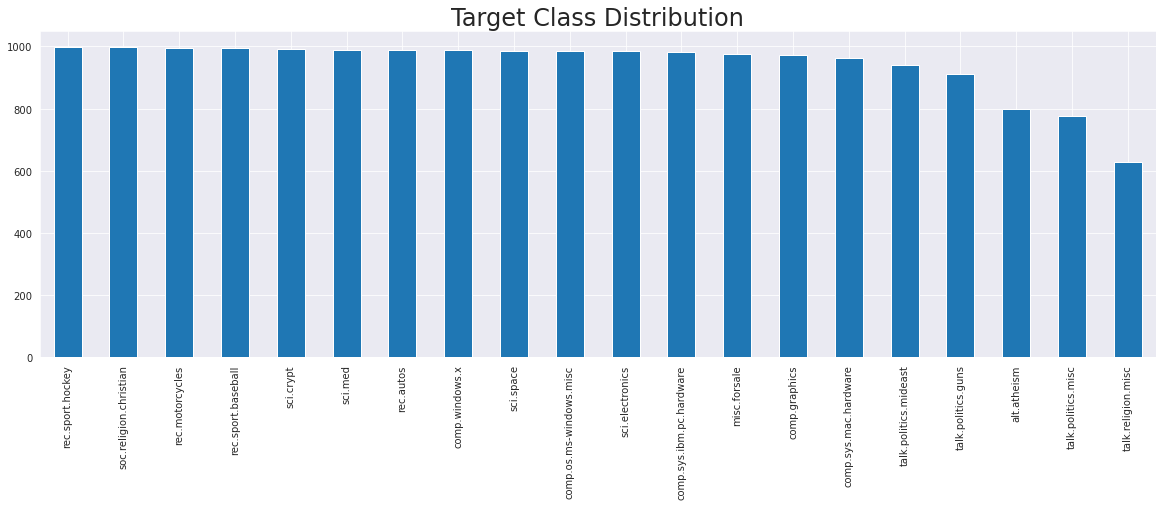

In [6]:
ax = dataset[config.TARGET].value_counts().plot.bar(figsize=(20, 6))
ax.set_title('Target Class Distribution', fontsize=24);

CPU times: user 46.2 s, sys: 946 ms, total: 47.2 s
Wall time: 47.4 s


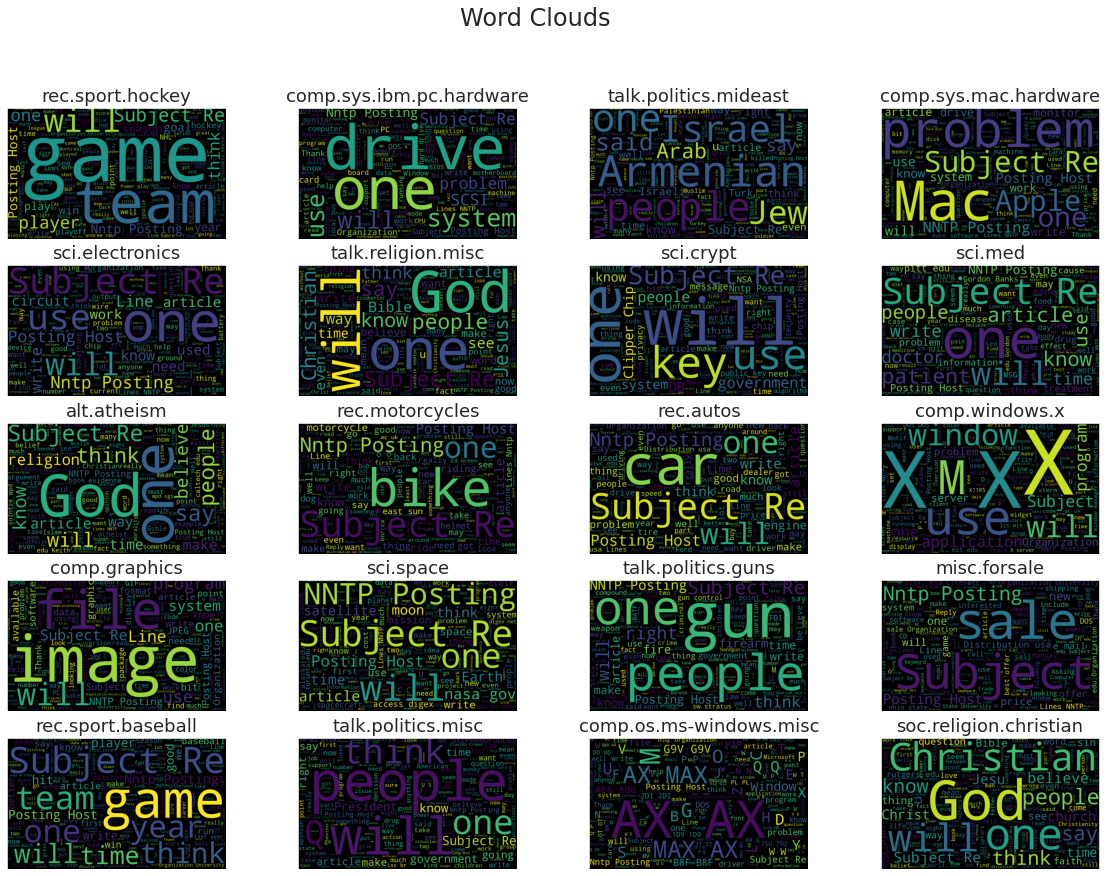

In [7]:
%%time

fig, ax = plt.subplots(5, 4, figsize=(20, 14))
fig.suptitle('Word Clouds', fontsize=24)
for i, label in enumerate(dataset[config.TARGET].unique()):
    wordcloud = WordCloud(height=600, width=1000, stopwords=STOPWORDS).generate(
        ' '.join(dataset[dataset[config.TARGET] == label][config.TEXT].values)
    )
    ax[i//4][i%4].imshow(wordcloud)
    ax[i//4][i%4].set_title(label, fontsize=18)
    ax[i//4][i%4].xaxis.set_visible(False)
    ax[i//4][i%4].yaxis.set_visible(False) 

# Cross Validation

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=19)
train_index, valid_index = list(sss.split(dataset[config.TEXT].values, dataset[config.TARGET]))[0]

In [9]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, x_train, x_valid, y_train, y_valid):
    print('Train Set:')
    print()
    print(classification_report(y_train, model.predict(x_train)))
    
    print()
    print()
    
    print('Validation Set:')
    print()
    print(classification_report(y_valid, model.predict(x_valid)))

In [10]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse=False).fit(dataset[[config.TARGET]])

x_train = dataset[config.TEXT][train_index].values
x_valid = dataset[config.TEXT][valid_index].values

y_train = ohe.transform(dataset[config.TARGET][train_index].values.reshape(-1, 1))
y_valid = ohe.transform(dataset[config.TARGET][valid_index].values.reshape(-1, 1))

# Modelling

In [11]:
from tensorflow.keras import Input, models, layers, callbacks, utils, optimizers

In [12]:
text_input = Input(shape=(), dtype=tf.string, name='text')
net = embeddings.BERTEncoder()(text_input)

net = layers.Dropout(0.1)(net)
net = layers.Dense(20, activation="softmax",name='classifier')(net)
classifier_model = models.Model(text_input, net)
classifier_model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-5), loss="categorical_crossentropy",  metrics=['acc']
)

In [13]:
classifier_model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
text (InputLayer)               [(None,)]            0                                            
__________________________________________________________________________________________________
preprocessing (KerasLayer)      {'input_type_ids': ( 0           text[0][0]                       
__________________________________________________________________________________________________
BERT_encoder (KerasLayer)       {'sequence_output':  28763649    preprocessing[0][0]              
                                                                 preprocessing[0][1]              
                                                                 preprocessing[0][2]              
______________________________________________________________________________________________

In [14]:
es = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, verbose=1, mode="min", restore_best_weights=True,
)

rlp = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.1, patience=3, verbose=1,  mode="min", min_delta=0.0001,
    min_lr=1e-15,
)

history = classifier_model.fit(
    x_train, y_train, validation_data=(x_valid, y_valid),
    epochs=100, callbacks=[es, rlp]
)

Epoch 1/100
531/531 [==============================] - 112s 201ms/step - loss: 1.9028 - acc: 0.4276 - val_loss: 0.6182 - val_acc: 0.8085
Epoch 2/100
531/531 [==============================] - 105s 198ms/step - loss: 0.5329 - acc: 0.8405 - val_loss: 0.4239 - val_acc: 0.8695
Epoch 3/100
531/531 [==============================] - 107s 201ms/step - loss: 0.2815 - acc: 0.9185 - val_loss: 0.3631 - val_acc: 0.8928
Epoch 4/100
531/531 [==============================] - 105s 199ms/step - loss: 0.1737 - acc: 0.9515 - val_loss: 0.3063 - val_acc: 0.9141
Epoch 5/100
531/531 [==============================] - 105s 198ms/step - loss: 0.0931 - acc: 0.9766 - val_loss: 0.3318 - val_acc: 0.9146
Epoch 6/100
531/531 [==============================] - 105s 198ms/step - loss: 0.0558 - acc: 0.9855 - val_loss: 0.3351 - val_acc: 0.9183
Epoch 7/100
531/531 [==============================] - 105s 197ms/step - loss: 0.0410 - acc: 0.9909 - val_loss: 0.3549 - val_acc: 0.9130

Epoch 00007: ReduceLROnPlateau reducing 

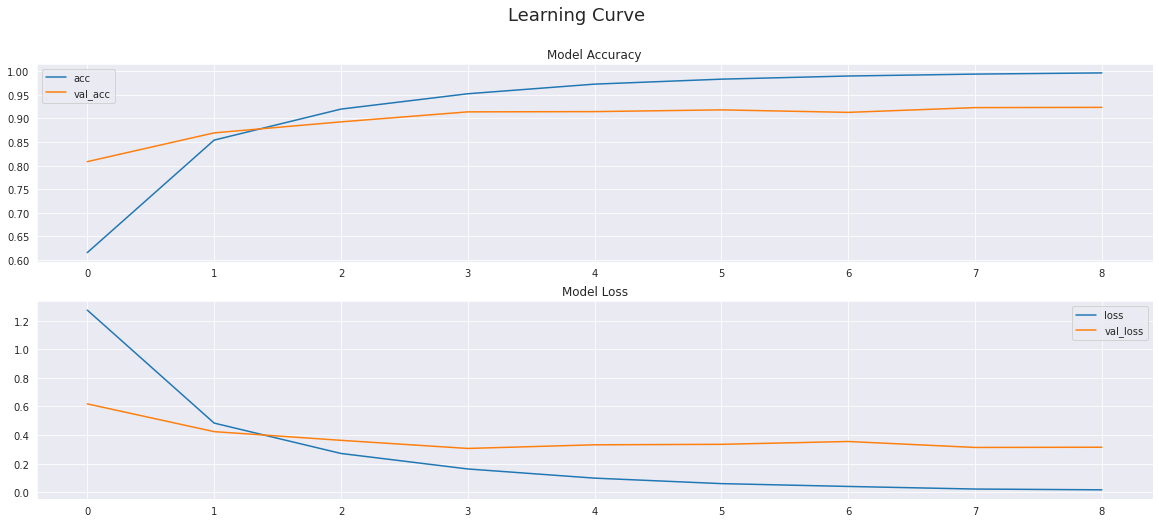

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(20, 8))
df = pd.DataFrame(history.history)
df[['acc', 'val_acc']].plot(ax=ax[0])
df[['loss', 'val_loss']].plot(ax=ax[1])
ax[0].set_title('Model Accuracy', fontsize=12)
ax[1].set_title('Model Loss', fontsize=12)
fig.suptitle('Learning Curve', fontsize=18);